# Data Programming in Python | BAIS:6040
# Notebook Demonstration 6.6 Pie Charts

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

C:\Users\redmo\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Pie Chart

In [2]:
df = pd.read_csv("taylor_swift_spotify.csv")

In [3]:
# 1. Let's call the songs that are less than 4 mintues 'Short Song' and those longer than 4 minutes 'Long Song'
# Add a column called 'Long' to determine which songs are short and which ones are long
# 2. Calculate the number of short and long songs
# 3. Draw a pie chart to display the results
df['duration'] = df['duration_ms']/1000
df['Long'] = ['Long Song' if d >= 4*60 else 'Short Song' for d in df['duration'] ]
df_long = df.groupby('Long').agg('count')
df_long

,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duration
Long,,,,,,,,,,,,,,,,,,
Long Song,251,251,251,251,251,251,251,251,251,251,251,251,251,251,251,251,251,251
Short Song,331,331,331,331,331,331,331,331,331,331,331,331,331,331,331,331,331,331


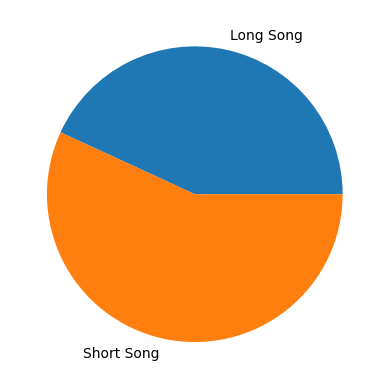

In [4]:
plt.pie(x=df_long['name'], labels=df_long.index)
plt.show()

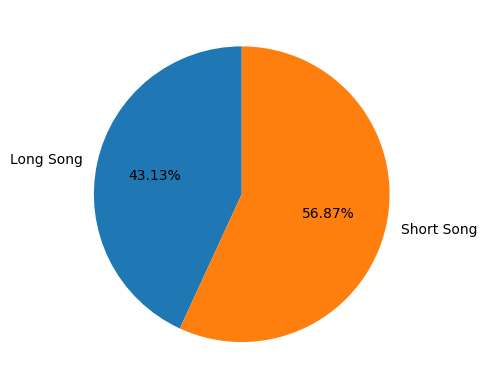

In [5]:
# Same as above but display the percentages and set the start angle to 90
plt.pie(x=df_long['name'], labels=df_long.index, autopct="%.2f%%", startangle=90)
plt.show()

In [6]:
# Create a category to determine the level of popularity of each song
# 75 <= popularity  : Popular
# 50 <= popularity < 75 : 'Somewhat Popular'
# popularity < 50 : 'Not Popular'

pop_categories = ['']*df.shape[0]
pop = df['popularity']
for i in range(df.shape[0]):
    if pop[i] >= 75:
        pop_categories[i] = 'Popular'
    elif pop[i] >= 50:
        pop_categories[i] = 'Somewhat Popular'
    else:
        pop_categories[i] = 'Not Popular'

df['Popular'] = pop_categories
df_pop = df.groupby('Popular').agg('count')
df_pop

,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duration,Long
Popular,,,,,,,,,,,,,,,,,,,
Not Popular,176,176,176,176,176,176,176,176,176,176,176,176,176,176,176,176,176,176,176
Popular,93,93,93,93,93,93,93,93,93,93,93,93,93,93,93,93,93,93,93
Somewhat Popular,313,313,313,313,313,313,313,313,313,313,313,313,313,313,313,313,313,313,313


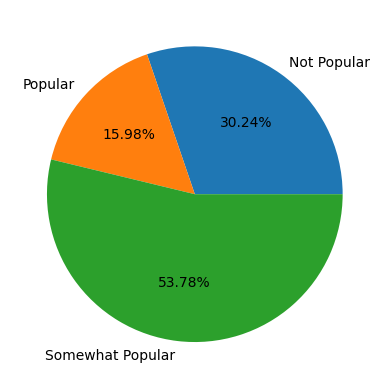

In [7]:
plt.pie(x=df_pop['name'], labels=df_pop.index, autopct="%.2f%%")
plt.show()

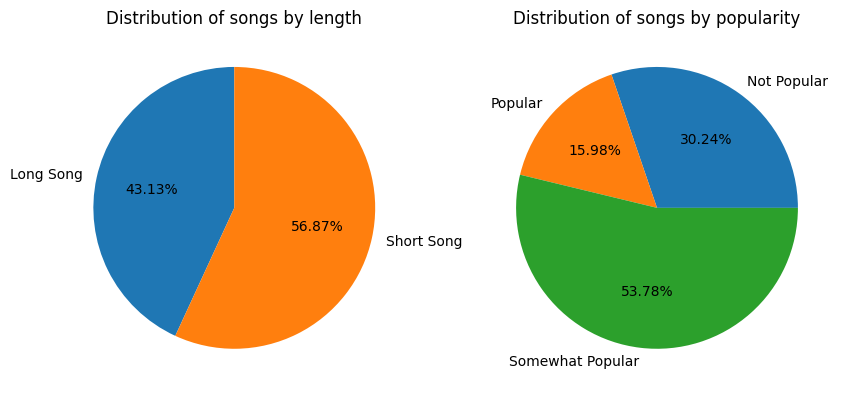

In [8]:
# Plotting both pie charts side-by-side

fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (10,5))

axs[0].pie(x=df_long['name'], labels=df_long.index, autopct="%.2f%%", startangle=90)
axs[0].set_title('Distribution of songs by length')

axs[1].pie(x=df_pop['name'], labels=df_pop.index, autopct="%.2f%%")
axs[1].set_title('Distribution of songs by popularity')

plt.show()

In [9]:
df = pd.read_csv("Reviews_update.csv", index_col=0)

In [10]:
# Count the frequency of each score
score_counts = df.Score.value_counts().sort_index()

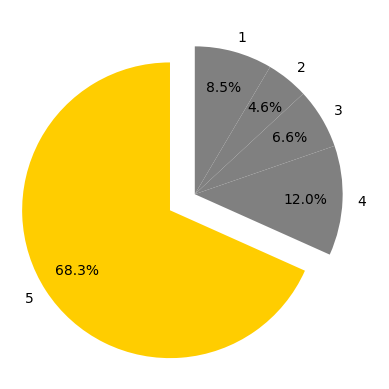

In [11]:
# Practice: plot the pie chart for review scores

explodes = [0, 0, 0, 0, 0.2]
plt.pie(score_counts, labels=score_counts.index, explode=explodes, autopct='%.1f%%', pctdistance=0.75, 
        colors=['gray', 'gray', 'gray', 'gray', '#FFCD00'], startangle=90, counterclock=False)

# To export the plot
plt.savefig("piechart.png", dpi=300)

plt.show()